**Importing Data**

In [ ]:
import pandas as pd

# Load the dataset from the CSV file
df = pd.read_csv("Iris.csv")

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [ ]:
# Drop the 'Id' column from the main DataFrame
df = df.drop(columns=['Id'])

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


**PreProcessing**

1- Handle Missing data

In [ ]:
df.isna().sum()

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
"""
df.dropna(inplace=True)
df.fillna(df.mean(), inplace=True)
"""

'\ndf.dropna(inplace=True)\ndf.fillna(df.mean(), inplace=True)\n'

2- Handle Duplicates

In [ ]:
df.drop_duplicates(inplace=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  147 non-null    float64
 1   SepalWidthCm   147 non-null    float64
 2   PetalLengthCm  147 non-null    float64
 3   PetalWidthCm   147 non-null    float64
 4   Species        147 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.9+ KB
None


In [ ]:
# Extract the 'Species' column into a separate variable
species = df['Species']
# Drop 'Species' column from the dataset
df = df.drop(columns=['Species'])

3- Encoding Categorical Data

In [ ]:
# Label Encoding
"""
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
species = encoder.fit_transform(species)
"""
# One-Hot Encoding
"""
df = pd.get_dummies(df, columns=['category'])
"""

"\ndf = pd.get_dummies(df, columns=['category'])\n"

*4*- Feature engineering

In [ ]:
# Add 'Petal_Area' and 'Size' column to the dataset
df['Petal_Area'] = df['PetalLengthCm'] * df['PetalWidthCm']
df['Size']= (df['PetalLengthCm'] * df['PetalWidthCm'] * df['SepalLengthCm'])

5- Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
# 1️⃣ Instanciate STandardScaler Object
scaler = StandardScaler()
# 2️⃣ Fit the scaler to the data
scaler.fit(df)
# 3️⃣ Transform the data
df = scaler.transform(df)

**Choosing Optimal K (Determining Hyperparameters)**

In [ ]:
from sklearn.cluster import KMeans
K=range(1,10)
Inertia=[]
for k in K:
  kmeans=KMeans(n_clusters=k)
  kmeans.fit(df)
  Inertia.append(kmeans.inertia_)


Text(0.5, 1.0, 'The Elbow Method')

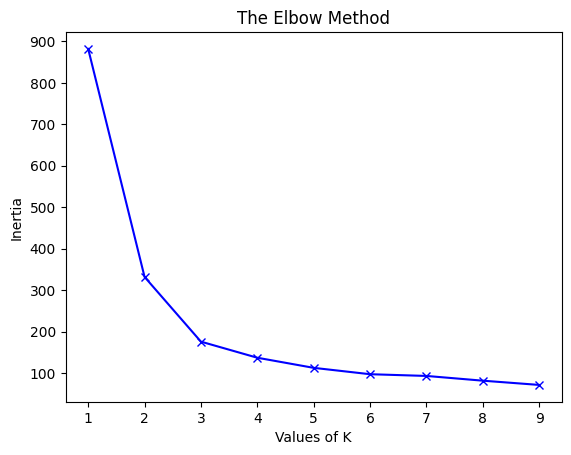

In [ ]:
import matplotlib.pyplot as plt
plt.plot(K,Inertia,'bx-')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('The Elbow Method')

**Now we fit the model with k=3**

In [ ]:
kmeans=KMeans(n_clusters=3)
kmeans.fit(df)

KMeans(n_clusters=3)

**Compare With the Actual Labels**

In [ ]:
labels=kmeans.labels_
pd.crosstab(labels,species)

Species,Iris-setosa,Iris-versicolor,Iris-virginica
row_0,,,
0,0,1,36
1,48,0,0
2,0,49,13


**Visualize Results**

Text(0.5, 1.0, 'K-Means Clustering')

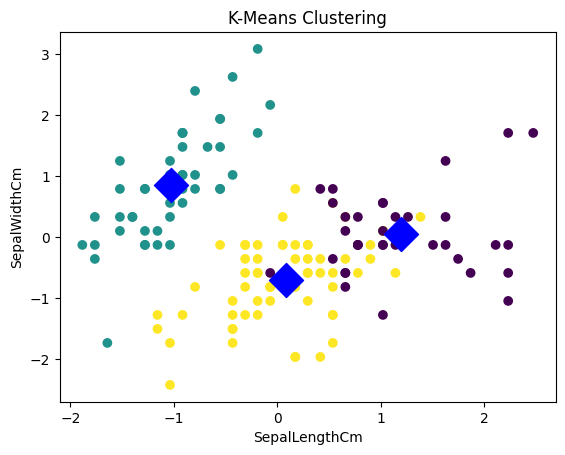

In [ ]:
plt.scatter(df[:,0], df[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],marker='D', s=300, c='Blue')
plt.xlabel('SepalLengthCm')
plt.ylabel('SepalWidthCm')
plt.title('K-Means Clustering')

**Visualisation Using Other Columns**

Text(0.5, 1.0, 'K-Means Clustering')

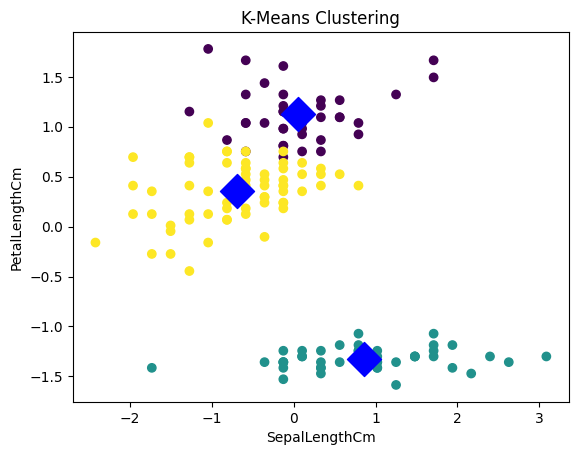

In [ ]:
plt.scatter(df[:,1], df[:,2], c=labels)
plt.scatter(kmeans.cluster_centers_[:,1],
            kmeans.cluster_centers_[:,2],marker='D', s=300, c='Blue')
plt.xlabel('SepalLengthCm')
plt.ylabel('PetalLengthCm')
plt.title('K-Means Clustering')

**Dimentionality Reduction (PCA)**

**Determine Intrinsic Dimension**

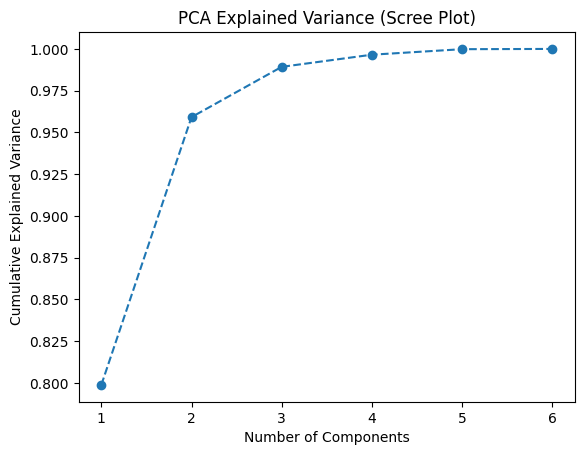

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Fit PCA once with all possible components
pca = PCA().fit(df)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plotting the "Elbow"
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance (Scree Plot)')
plt.show()

The **Intrinsic Dimension** of the Iris dataset is 2. (or 3)

Now we fit the model and transform the data.

In [ ]:
pca=PCA(n_components=2)
df_pca=pca.fit_transform(df)
centroids_pca=pca.transform(kmeans.cluster_centers_)

Text(0.5, 1.0, 'K-Means Clustering')

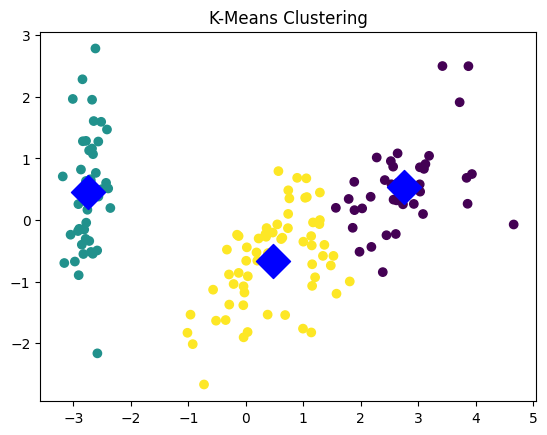

In [ ]:
plt.scatter(df_pca[:,0], df_pca[:,1], c=labels)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],marker='D', s=300, c='Blue')
plt.title('K-Means Clustering')

Check Explained Variance Ratio

In [ ]:
print(pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum()*100)


[0.79876982 0.16037628]
Total variance explained: 95.91461004726169


**Silhouette Score**

\> 0.5 → Good separation between clusters

0.3–0.5 → Acceptable but overlapping clusters

< 0.3 → Poor clustering

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_score(df, labels)

np.float64(0.5149906951430419)